# Clase 1 — Fundamentos del Aprendizaje Automático
**Introducción a la Minería de Datos · Universidad Nacional de Colombia, Medellín**

---
### Objetivos de este notebook
1. Configurar el entorno de trabajo con las librerías estándar de ML
2. Explorar y preparar un dataset real
3. Aplicar el ciclo Representar → Entrenar → Evaluar → Refinar
4. Visualizar overfitting y underfitting en la práctica

**Dataset:** Precios de vivienda (`California Housing` de scikit-learn) + datos sintéticos para ilustrar conceptos.

> 💡 **Cómo trabajar este notebook:** ejecuta cada celda en orden (`Shift+Enter`). Las celdas marcadas con ✏️ tienen ejercicios para completar.

## 0. Importaciones y configuración

In [1]:
# ── Librerías estándar ──────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ────────────────────────────────────────
from sklearn.datasets        import fetch_california_housing, make_regression # datasets
from sklearn.model_selection import train_test_split, learning_curve #división de datos y curvas de aprendizaje
from sklearn.preprocessing   import StandardScaler # estandarización media 0 y varianza 1 en los datos
#recordemos que la normalización lo que hace es llevar la variable a la escala 0 a 1
from sklearn.linear_model    import LinearRegression #regresión lineal
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, r2_score #métricas de evaluación para un modelo de regresión

# ── Estética ────────────────────────────────────────────
# fondo blanco y paleta de colores viridis para todos los gráficos
sns.set_theme(style='whitegrid', palette='viridis')

# ajusta resolución de matplotlib a 110 puntos por pulgada y 
# define el tamaño de las figuras a 9x5.
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 5)})

#definir la semilla para que todo sea reproducible. 
SEED = 42
np.random.seed(SEED)

print('✓ Entorno listo')

✓ Entorno listo


## 1. El problema — datos de vivienda

Usamos el dataset **California Housing** (20,640 distritos de California, 1990).  
Es análogo a nuestro ejemplo de Medellín: características de la zona → precio mediano.

In [2]:
data = fetch_california_housing(as_frame=True) #instancia de los datos
# as_frame=True sirve que los datos se entreguen en la forma de un data_frame
#de pandas en lugar de arreglos bidimensionales de numpy.

#print(type(data))
#print(data.target_names) # variable objetivo
#print(data.data) primer vistazo


In [3]:
# Cargar datos
df   = data.frame #se vuelve un data frame
print(f'tipo {type(df)}')
print(f'Shape: {df.shape}') #alrededor de 20600 filas x 9 columnas
print(f'Target: precio mediano de la vivienda (en 100,000 USD). \n nombre variable objetivo {data.target_names}')

df.head()

tipo <class 'pandas.DataFrame'>
Shape: (20640, 9)
Target: precio mediano de la vivienda (en 100,000 USD). 
 nombre variable objetivo ['MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Tipos de coulumnas
df.dtypes # tdas las columnas son de tipo de numérico


MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [5]:
# Estadísticas descriptivas — como estadísticos, esto es lo primero
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


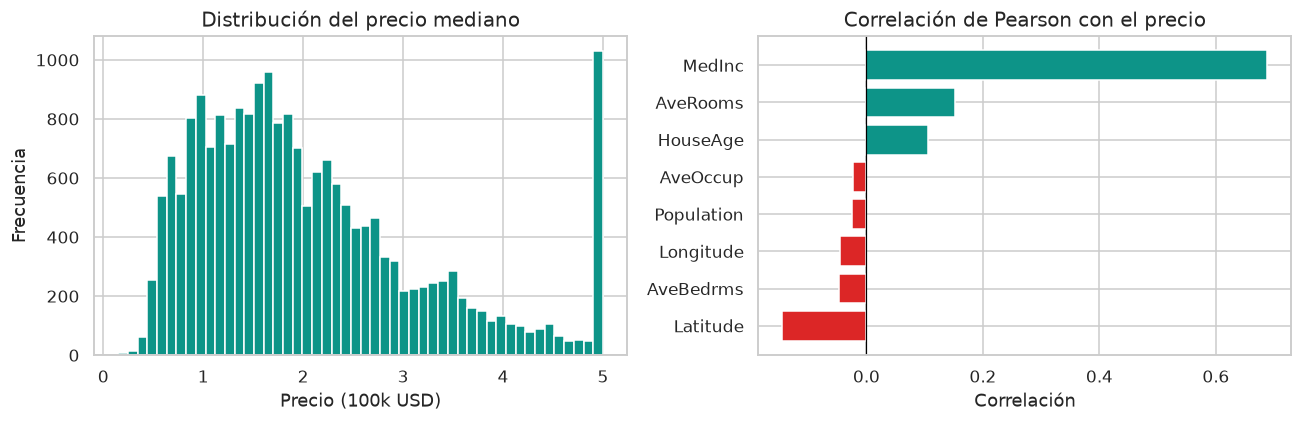


Variable más correlacionada: MedInc


In [6]:
# Distribución del target y correlaciones
# 1 fila 2 columnas cada uno de 12x4
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del precio, en la primera gráfica, un histograma
# de la variable objetivo, con 50 bins, 
axes[0].hist(df['MedHouseVal'], bins=50, color='#0D9488', edgecolor='white')
axes[0].set_title('Distribución del precio mediano', fontsize=13) #título
axes[0].set_xlabel('Precio (100k USD)') # título eje X
axes[0].set_ylabel('Frecuencia') #título eje Y

# Correlación con el target
corrs = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()

# si la correlación es negativa en rojo, si es positiva en azúl.
colors = ['#DC2626' if c < 0 else '#0D9488' for c in corrs]
axes[1].barh(corrs.index, corrs.values, color=colors) #tipo de gráfica
#corrs.index es el nombre de las columnas y pues lo otro los valores
axes[1].axvline(0, color='black', linewidth=0.8) #poner una linea negra en x = 0
axes[1].set_title('Correlación de Pearson con el precio', fontsize=13) #título
axes[1].set_xlabel('Correlación') #título eje X

plt.tight_layout() # que el texto se agregue bien 
plt.show() #mostrar

#mostrar el índice de la mayor correlación (las varibles son los índices)
print('\nVariable más correlacionada:', corrs.abs().idxmax())

In [7]:
df.corr()#matriz de correlaciones completa

#df.corr()['MedHouseVal'] #traer solo las correlaciones de la variable objetivo

#df.corr()['MedHouseVal'].drop(['MedHouseVal']) #elminar la correlacion con ella misma
#según su índice. drop por defecto elimina por filas, y axis=1 por columnas

#df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values() #ordenar los valores

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


## 2. El ciclo ML — Representar → Entrenar → Evaluar

In [8]:
# ── PASO 1: Representar — definir X e y ─────────────────
# Representar tiene que ver con el pre-procesamiento que llevamos a cabo con nuestros datos
# escalar, estandarizar, normalizar y la ingeniería de características que se necesita para
# para el entrno de los modelos. 

#Primero definimos la matriz de los datos
X = df.drop(columns=['MedHouseVal']) #quitando la variable objetivo
# se puede hacer df.drop(['MedHouseVal'], axis=1)

#Definimos el vector de la variable respuesta
y = df['MedHouseVal'] 

print(f'X: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} features')
print(f'y: {y.shape}  →  variable continua (regresión)')

X: (20640, 8)  →  20640 muestras, 8 features
y: (20640,)  →  variable continua (regresión)


In [9]:
# ── PASO 2: División entrenamiento / prueba ──────────────
#Se hacen las divisiones aleatorias del conjunto de entrenamiento
#X_train y y_train y de prueba X_test, y_test, con una separación
# de 80% y 20% de los datos respectivamente son la semilla ya definida
#en la parte de las librerias. 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

#Nota: la sincronización entre las características 'X' y sus 
#etiquetas correspondientes 'y' es estrica fila por fila gracias
# a sus índices. En este caso se usa el random_state para la semilla
# de la aleatorización de los datos. En caso de que 'Y' fuera una
#variable categórica entonces hay que usar el stratify='y' que es
# un muestreo por estratificación y tomar las proporciones por categoría. 


print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print()
print('REGLA DE ORO: a partir de aquí, X_test y y_test')
print('NO se tocan hasta la evaluación final.')

Entrenamiento: 16512 muestras
Prueba:        4128 muestras

REGLA DE ORO: a partir de aquí, X_test y y_test
NO se tocan hasta la evaluación final.


In [10]:
# Verificamos que los índices de las filas sean exactamente los mismos
print((X_train.index == y_train.index).all())
# Salida: True

print((X_test.index == y_test.index).all())
# Salida: True

True
True


In [11]:
#Notese que ambos siguen siendo data frames. 
print(type(X_train))
print(type(X_test))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [12]:
# ── PASO 3: Entrenar — usando un Pipeline ───────────────
# Pipeline = escalar + modelo en una sola cadena
pipe = Pipeline([
    ('scaler', StandardScaler()),      # normaliza a media 0, desv. 1
    ('model',  LinearRegression()),    #luego ajustar una regresión lineal
])

pipe.fit(X_train, y_train) # necesitamos tanto el X_train y Y_train
#al igual que si se hace manula y se hace con la instancia del modelo. 
print('✓ Modelo entrenado')

✓ Modelo entrenado


In [13]:
# ── PASO 4: Evaluar ─────────────────────────────────────
y_pred_train = pipe.predict(X_train) # predicciones del conjunto de entrenamiento
y_pred_test  = pipe.predict(X_test) #predicciones del conjunto de prueba.

# Calcular MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

# Calcular RMSE
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

# Calcular R^2
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print(f'{'Métrica':<12} {'Entrenamiento':>16} {'Prueba':>10}')
print('-' * 42)
print(f'{'RMSE':<12} {rmse_train:>16.3f} {rmse_test:>10.3f}')
print(f'{'R²':<12} {r2_train:>16.3f} {r2_test:>10.3f}')

print()
# Diagnóstico automático
gap = rmse_test - rmse_train
if gap < 0.05:
    print('✓ Diferencia train/test pequeña → buen ajuste')
elif gap < 0.15:
    print('⚠ Leve overfitting — considerar regularización')
else:
    print('✗ Overfitting importante — el modelo no generaliza bien')

Métrica         Entrenamiento     Prueba
------------------------------------------
RMSE                    0.720      0.746
R²                      0.613      0.576

✓ Diferencia train/test pequeña → buen ajuste


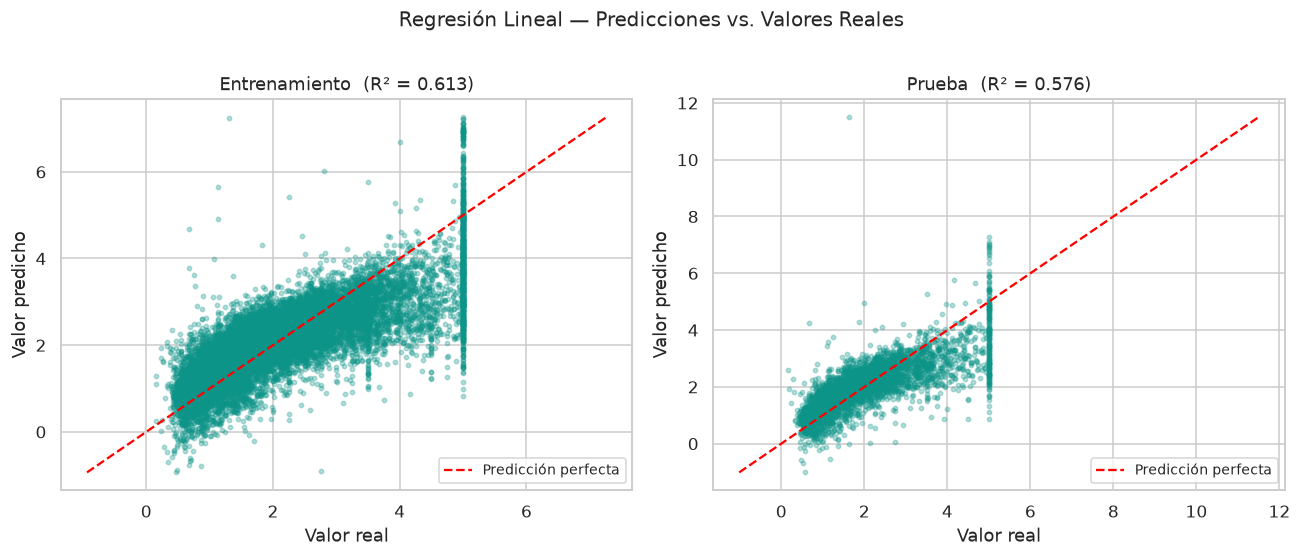

In [14]:
# Gráfico de predicciones vs. valores reales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_p, label) in zip(axes, [
    (y_train, y_pred_train, 'Entrenamiento'),
    (y_test,  y_pred_test,  'Prueba')
]):
    ax.scatter(y_true, y_p, alpha=0.3, s=8, color='#0D9488')
    lims = [min(y_true.min(), y_p.min()), max(y_true.max(), y_p.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')
    ax.set_title(f'{label}  (R² = {r2_score(y_true, y_p):.3f})')
    ax.legend(fontsize=9)

plt.suptitle('Regresión Lineal — Predicciones vs. Valores Reales', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

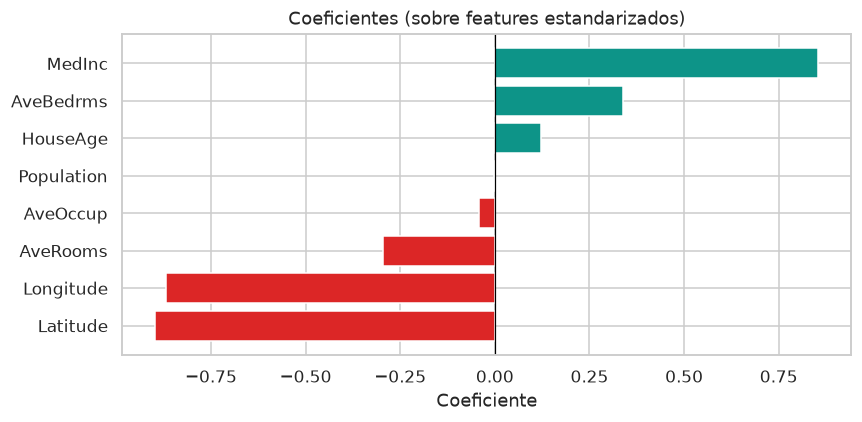

Intercepto: 2.072


In [15]:
# Coeficientes del modelo — interpretación estadística
coef = pd.Series(
    pipe.named_steps['model'].coef_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if c < 0 else '#0D9488' for c in coef]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes (sobre features estandarizados)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('Intercepto:', pipe.named_steps['model'].intercept_.round(3))

min 1:21:00

## 3. Visualizar Overfitting y Underfitting

Usamos un dataset sintético con señal no lineal para ver los tres escenarios.

antes del redimensionamiento: (80,) y tipo <class 'numpy.ndarray'>
antes del redimensionamiento: (80, 1) y tipo <class 'numpy.ndarray'>


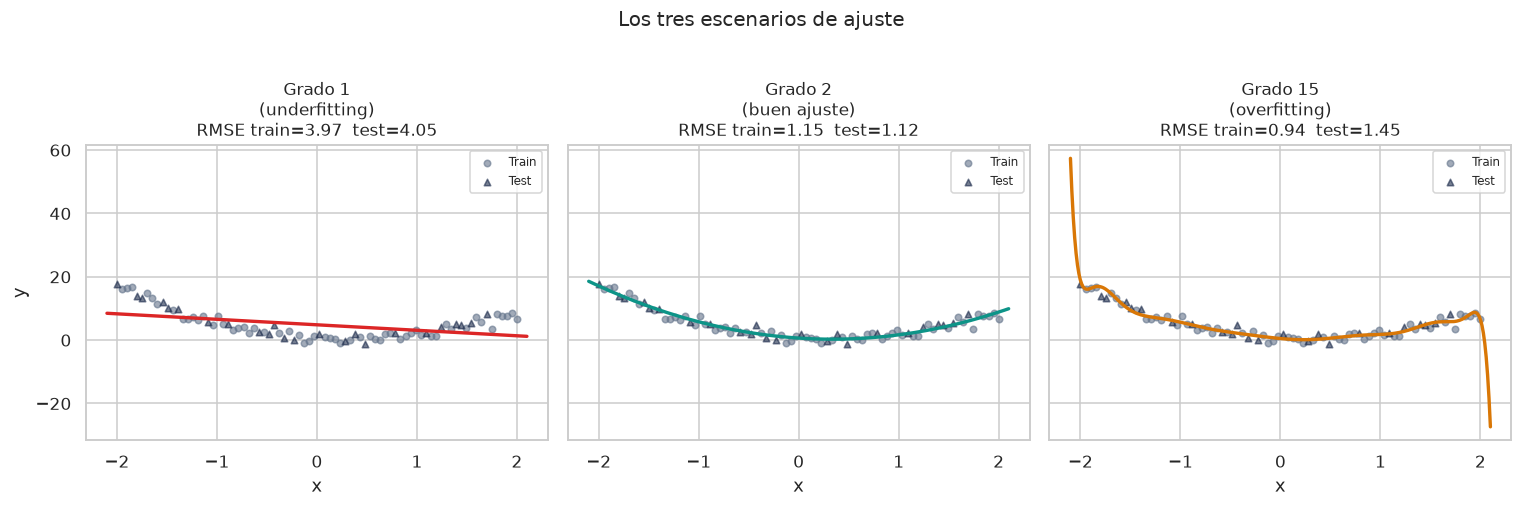

In [ ]:
#para crear potencias de la varible original para crear un modelo polinomial
from sklearn.preprocessing   import PolynomialFeatures

#Para crear el pipline
from sklearn.pipeline        import make_pipeline

# Dataset sintético: y = 3x² - 2x + 1 + ruido
np.random.seed(SEED) #semilla 42
n = 80 # número de datos
x_syn = np.linspace(-2, 2, n) #crea los 80 puntos equiespaciados
#entre -2 y 2.

# Generar los datos usando la ecuación cuadrática
#y se le añade el ruido blanco con media 0 y varianza constante 1.2
y_syn = 3*x_syn**2 - 2*x_syn + 1 + np.random.normal(0, 1.2, n)



X_syn = x_syn.reshape(-1, 1) #convertir la lista de 1 dimensión
#a un arreglo bidimensional con 1 sola columna, exigido por scikit-learn.

#es un vector
print(f"antes del redimensionamiento: {x_syn.shape} y tipo {type(x_syn)}")

#lo pasamos como matriz
print(f"antes del redimensionamiento: {X_syn.shape} y tipo {type(X_syn)}")

#separación para entrenamiento y prueba. Recordemos que 
#si se pone primero X_syn en los argumentos primero va 
# X_entrenamiento y luego X_prueba
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.3, random_state=SEED)

# Modelos de distinta complejidad
#Ahora probar modelos para ver como es su ajuste
grados = [1, 2, 15]          # underfitting, correcto, overfitting
labels = ['Grado 1\n(underfitting)', 'Grado 2\n(buen ajuste)', 'Grado 15\n(overfitting)']
colors_m = ['#DC2626', '#0D9488', '#D97706']

#configurar gráfica, AJUSTE DE MODELOS RESPECTO A LA RESPUESTA
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

# 300 puntos suaves para poder dibujar la curva ajustada
#de forma coninua en las gráficas
x_plot = np.linspace(-2.1, 2.1, 300).reshape(-1, 1)

#entrenamiento, evaluciación y graficado
for ax, grado, label, color in zip(axes, grados, labels, colors_m):

    #crear el pipeline
    m = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    #recordemos que PolynomialFeatures crea las varibles
    #de grado superior e interacciones si es el caso. 

    #ajustar el pipeline guardando los coeficientes. 
    m.fit(Xtr, ytr)

    #cálculo de métricas de entreno y prueba
    # ytr_real - ytr_ajustado al cuadrado
    mse_tr = mean_squared_error(ytr, m.predict(Xtr))
    mse_te = mean_squared_error(yte, m.predict(Xte))

    #raíz
    rmse_tr = np.sqrt(mse_tr)
    rmse_te = np.sqrt(mse_te)

    #que sean gráfico de dispersión
    ax.scatter(Xtr, ytr, s=18, alpha=0.6, color='#64748B', label='Train')
    ax.scatter(Xte, yte, s=18, alpha=0.6, color='#1B2A4A', label='Test', marker='^')

    ax.plot(x_plot, m.predict(x_plot), color=color, linewidth=2.2)
    ax.set_title(f'{label}\nRMSE train={rmse_tr:.2f}  test={rmse_te:.2f}', fontsize=11)
    ax.set_xlabel('x')

    if ax == axes[0]: ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Los tres escenarios de ajuste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Modelo de grado 1: RMSE alto en entreno y test, es decir, el modelo no logra captar la variabilidad intrínseca de los datos. 

Modelo de grado 2: RMSE bajo en entreno y test, por tanto, hay un nivel de estabilidad en ambas situaciones por lo que es un buen ajuste. 

Modelo de grado 15: RMSE bajo en entrenamiento pero más alto en test lo que quiere decir que aprendió mucho los datos del entreno pero no supo trabajar con los de entreno, por tanto, hay sobreajuste. 

Estas son las famosas curvas de aprendizaje para la evaluación del ajuste de los modelos. 

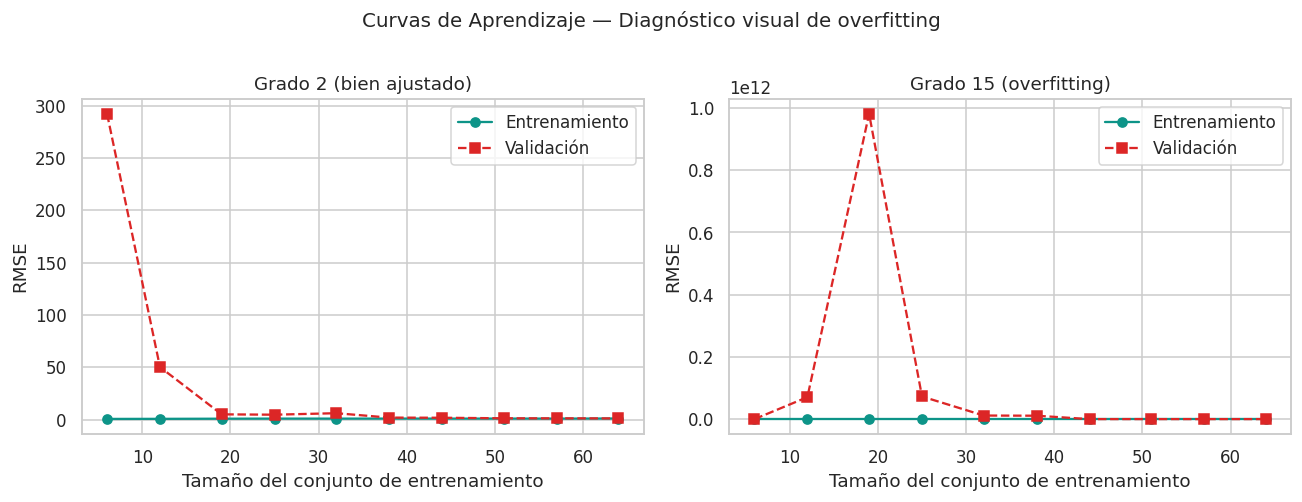


Interpretación:
  Grado 2:  curvas convergen → modelo equilibrado
  Grado 15: gap grande entre train y val → overfitting


In [ ]:
#GRÁFICAS DE CURVAS DE APRENDIZAJE ---------------------------------
#2 gráficas, 1 fila, 2 columnas de 12 x 4.5
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

#recorrer 3 listas en paralelo de longitud 2
for ax, grado, titulo in zip(axes, [2, 15], ['Grado 2 (bien ajustado)', 'Grado 15 (overfitting)']):

    #Crear un pipeline que primero eleva la variable x a las potencias del grado
    #actual, ya sean 2 o 15 y luego entrena una regresión lineal. 
    m = make_pipeline(PolynomialFeatures(grado), LinearRegression())

    #la función PolynomialFeatutres(2) para una variable X crea X y X^2
    # y pues linearRegression es para ajustar un modelo de regresión lienal. 

    #cálculo de la curva de aprendizaje:
    #la función learning curve evalua el comportamiento dle conjunto
    # del modelo aumentando progresivamente el tamaño del conjunto 
    # de datos m, X_syn, y_syn: El modelo a evaluar y la totalidad del dataset.
    # cv=5 es validación cruzada en 5 pliegues, entrenando en 4 y validando en 1. 
    #train_sizes=np.linspace(0.1, 1.0, 10): Entrena el modelo usando
    # desde el 10% hasta el 100% de los datos disponibles, en 10
    #  pasos incrementales (10%, 20%, 30%, ..., 100%).
    train_sizes, train_scores, val_scores = learning_curve(
        m, X_syn, y_syn, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_root_mean_squared_error',
        random_state=SEED
    )

    # train_sizes: Retorna las cantidades exactas de muestras usadas en cada paso.

    tr_m = -train_scores.mean(axis=1) #ajuste de signos y promedios
    va_m = -val_scores.mean(axis=1)

    ax.plot(train_sizes, tr_m, 'o-', color='#0D9488', label='Entrenamiento')
    ax.plot(train_sizes, va_m, 's--', color='#DC2626', label='Validación')
    ax.fill_between(train_sizes,
                    tr_m - train_scores.std(axis=1),
                    tr_m + train_scores.std(axis=1), alpha=0.15, color='#0D9488')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('RMSE')
    ax.legend()

plt.suptitle('Curvas de Aprendizaje — Diagnóstico visual de overfitting', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print('Interpretación:')
print('  Grado 2:  curvas convergen → modelo equilibrado')
print('  Grado 15: gap grande entre train y val → overfitting')

Más adelante entenderemos validación cruzada.

## 4. Parámetros e Hiperparámetros en la práctica

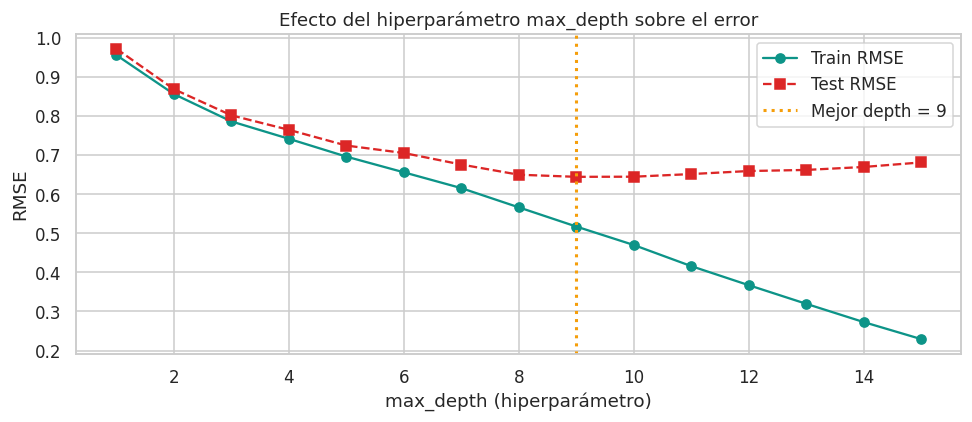

Mejor profundidad según test RMSE: 9
Nota: esta selección TAMBIÉN debería hacerse con validación cruzada (Clase 2)


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Efecto del hiperparámetro max_depth en un árbol de decisión
profundidades = range(1, 16)
rmse_tr_list, rmse_te_list = [], []

for d in profundidades:
    tree = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    tree.fit(X_train, y_train)

    mse_tr = mean_squared_error(y_train, tree.predict(X_train))
    mse_te = mean_squared_error(y_test,  tree.predict(X_test))

    rmse_tr_list.append(np.sqrt(mse_tr))
    rmse_te_list.append(np.sqrt(mse_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(profundidades, rmse_tr_list, 'o-', color='#0D9488', label='Train RMSE')
ax.plot(profundidades, rmse_te_list, 's--', color='#DC2626', label='Test RMSE')
mejor_d = profundidades[np.argmin(rmse_te_list)]
ax.axvline(mejor_d, color='#F59E0B', linestyle=':', linewidth=2, label=f'Mejor depth = {mejor_d}')
ax.set_xlabel('max_depth (hiperparámetro)')
ax.set_ylabel('RMSE')
ax.set_title('Efecto del hiperparámetro max_depth sobre el error', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor profundidad según test RMSE: {mejor_d}')
print('Nota: esta selección TAMBIÉN debería hacerse con validación cruzada (Clase 2)')

cuidado, no hay que tomar decisiones a partir de los datos de test. Estos no se pueden usar para diseñar el modelo y esto no se puede. No se pueden tomar decisiones con esos datos para no dañar la capacidad de generalización.

## ✏️ Ejercicios

### Ejercicio 1 — Exploración del dataset
Identificar las 3 features con mayor correlación absoluta con el precio.  
¿Tienen sentido desde el punto de vista económico?

In [ ]:
# Tu código aquí
# Pista: df.corr()['MedHouseVal'].abs().sort_values(ascending=False)


### Ejercicio 2 — Una sola variable
Ajustar una regresión lineal usando únicamente la variable `MedInc`.  
Comparar el R² con el modelo de todas las variables.  
¿Cuánta varianza explica solo el ingreso mediano?

In [ ]:
# Tu código aquí
# Pista: X_medinc = df[['MedInc']]


### Ejercicio 3 — Diagnóstico
Para el modelo con `max_depth=1` y con `max_depth=15`, imprimir:
- RMSE en entrenamiento
- RMSE en prueba  
- ¿Cuál tiene overfitting? ¿Cuál underfitting? Justificar.

In [ ]:
# Tu código aquí


---
## Resumen

| Concepto | Lo que aprendimos |
|----------|------------------|
| **EDA** | Siempre explorar antes de modelar — correlaciones, distribuciones |
| **Train/Test split** | Separar ANTES de tocar los datos |
| **Pipeline** | Escalar + modelar en un solo objeto → evita data leakage |
| **Overfitting** | RMSE test >> RMSE train; solución: regularización, más datos |
| **Underfitting** | RMSE alto en ambos conjuntos; solución: modelo más complejo |
| **Hiperparámetros** | Se eligen por validación — nunca usando el test set |

**Próxima clase:** métricas de clasificación, regularización L1/L2 y validación cruzada.